In [3]:
from utils.binaries import *
from utils.plotting import *

22:52:36 ( +942.5s) [INFO   ] -- import logging


22:52:36 (  +152ms) [INFO   ] -- import numpy as np
22:52:36 (    +6ms) [INFO   ] -- import uncertainties
22:52:36 (    +6ms) [INFO   ] -- import uncertainties
22:52:37 (  +324ms) [INFO   ] -- import pandas as pd
22:52:37 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
22:52:37 (    +2ms) [INFO   ] -- import binaries.tools as tools
22:52:37 (  +290ms) [INFO   ] -- import matplotlib.pyplot as plt
22:52:38 (  +591ms) [INFO   ] -- import seaborn as so
22:52:38 (    +2ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
22:52:38 (    +0ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
22:52:38 (    +1ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
22:52:38 (    +0ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
22:52:38 (    +1ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
22:52:38 (    +1ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offl

00:47:34 (  +11.4s) [DEBUG  ] -- font size set to 9.5
00:47:34 (    +1ms) [DEBUG  ] -- label size set to 13.0
00:47:34 (    +1ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
00:47:34 (    +1ms) [DEBUG  ] -- markersize set to 2.0
00:47:34 (    +0ms) [DEBUG  ] -- usetex set to True


Text(0.05, 0.05, '$\\beta = -1$')

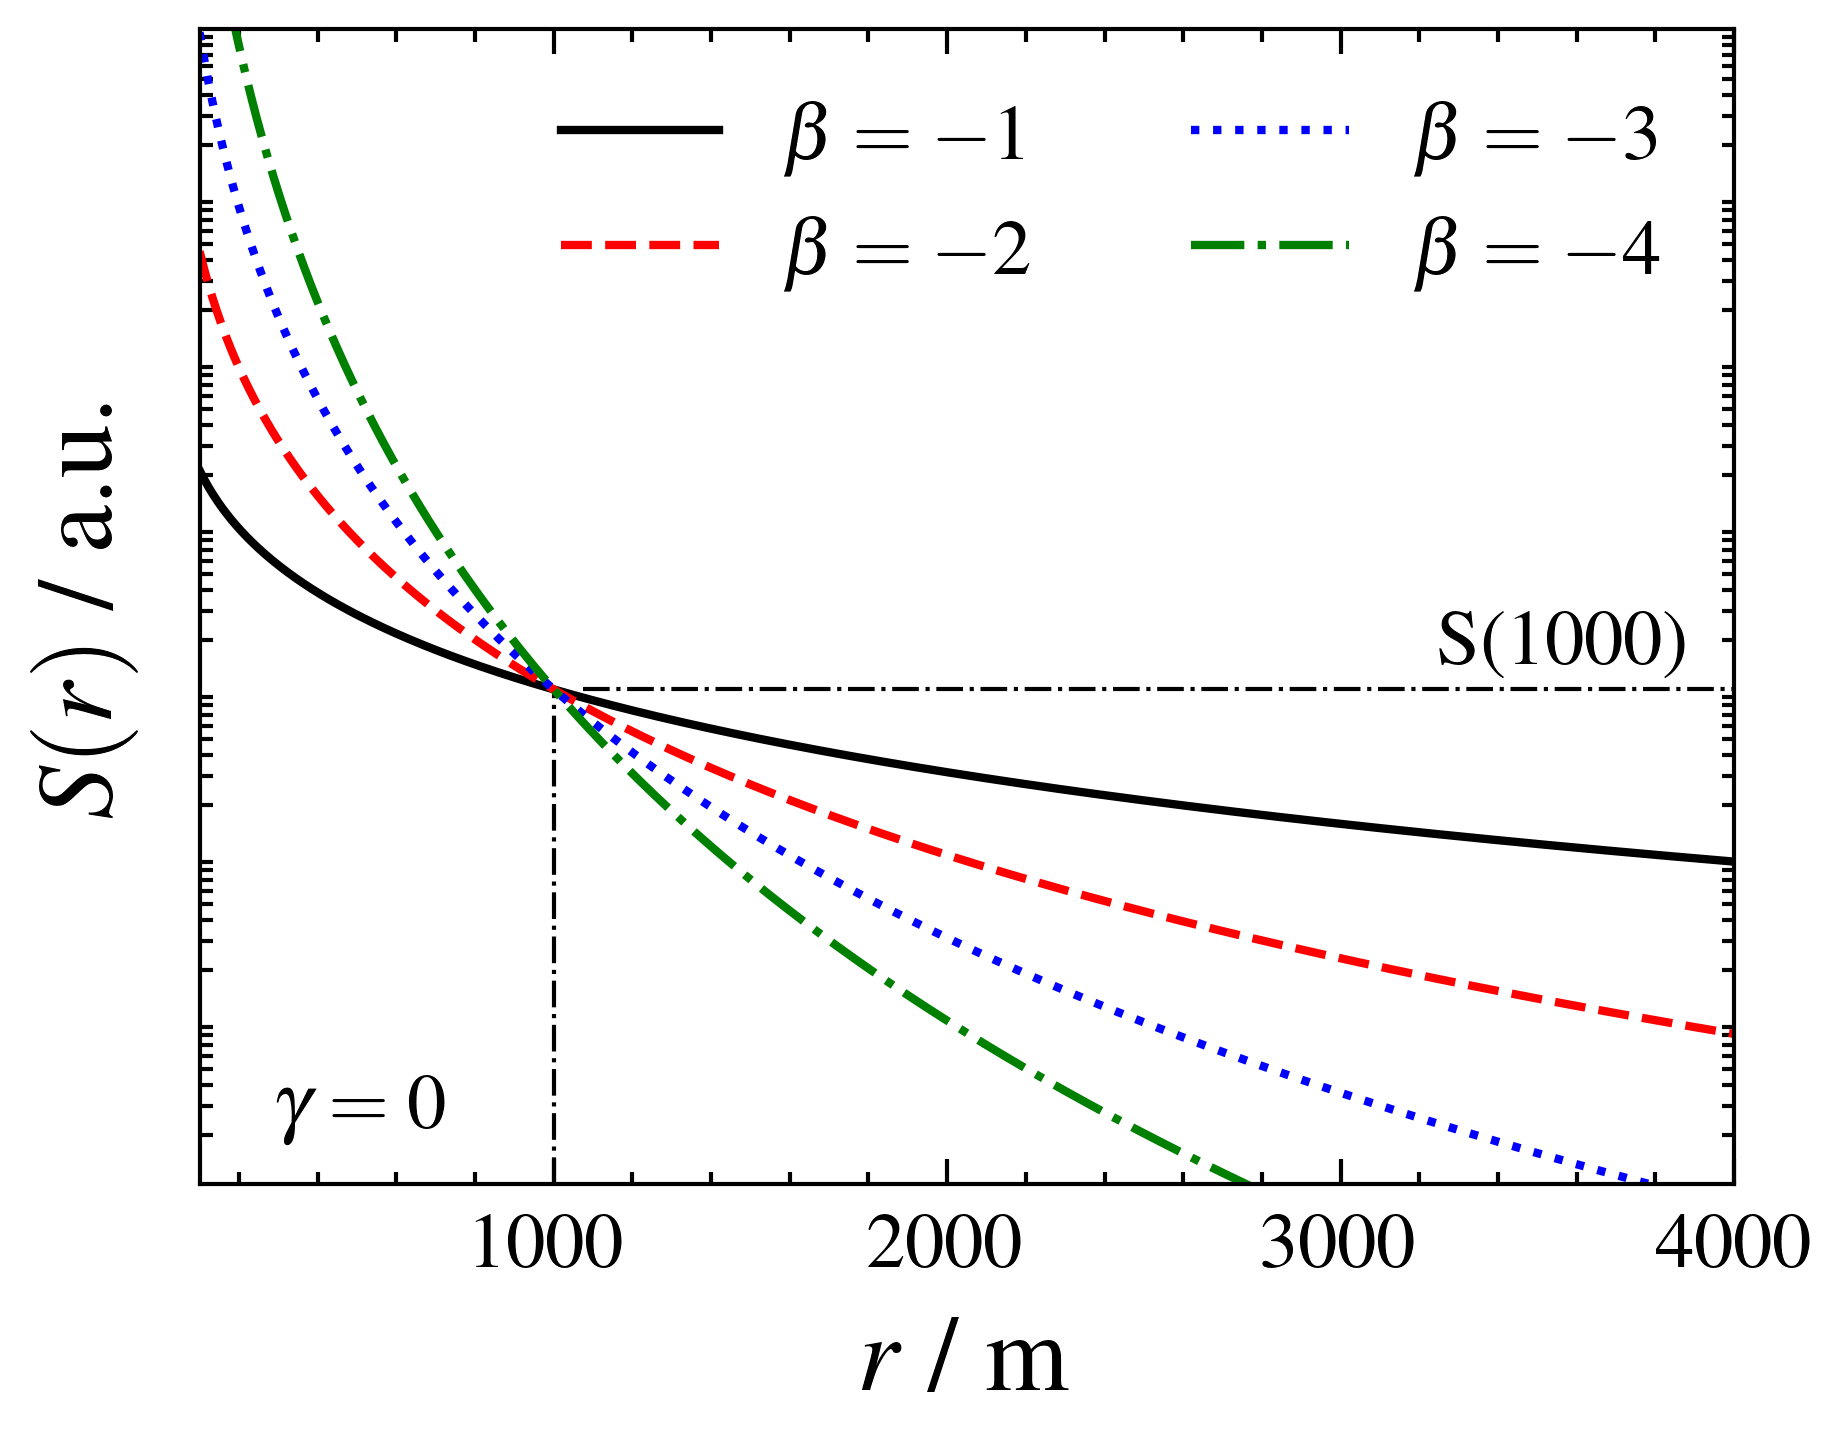

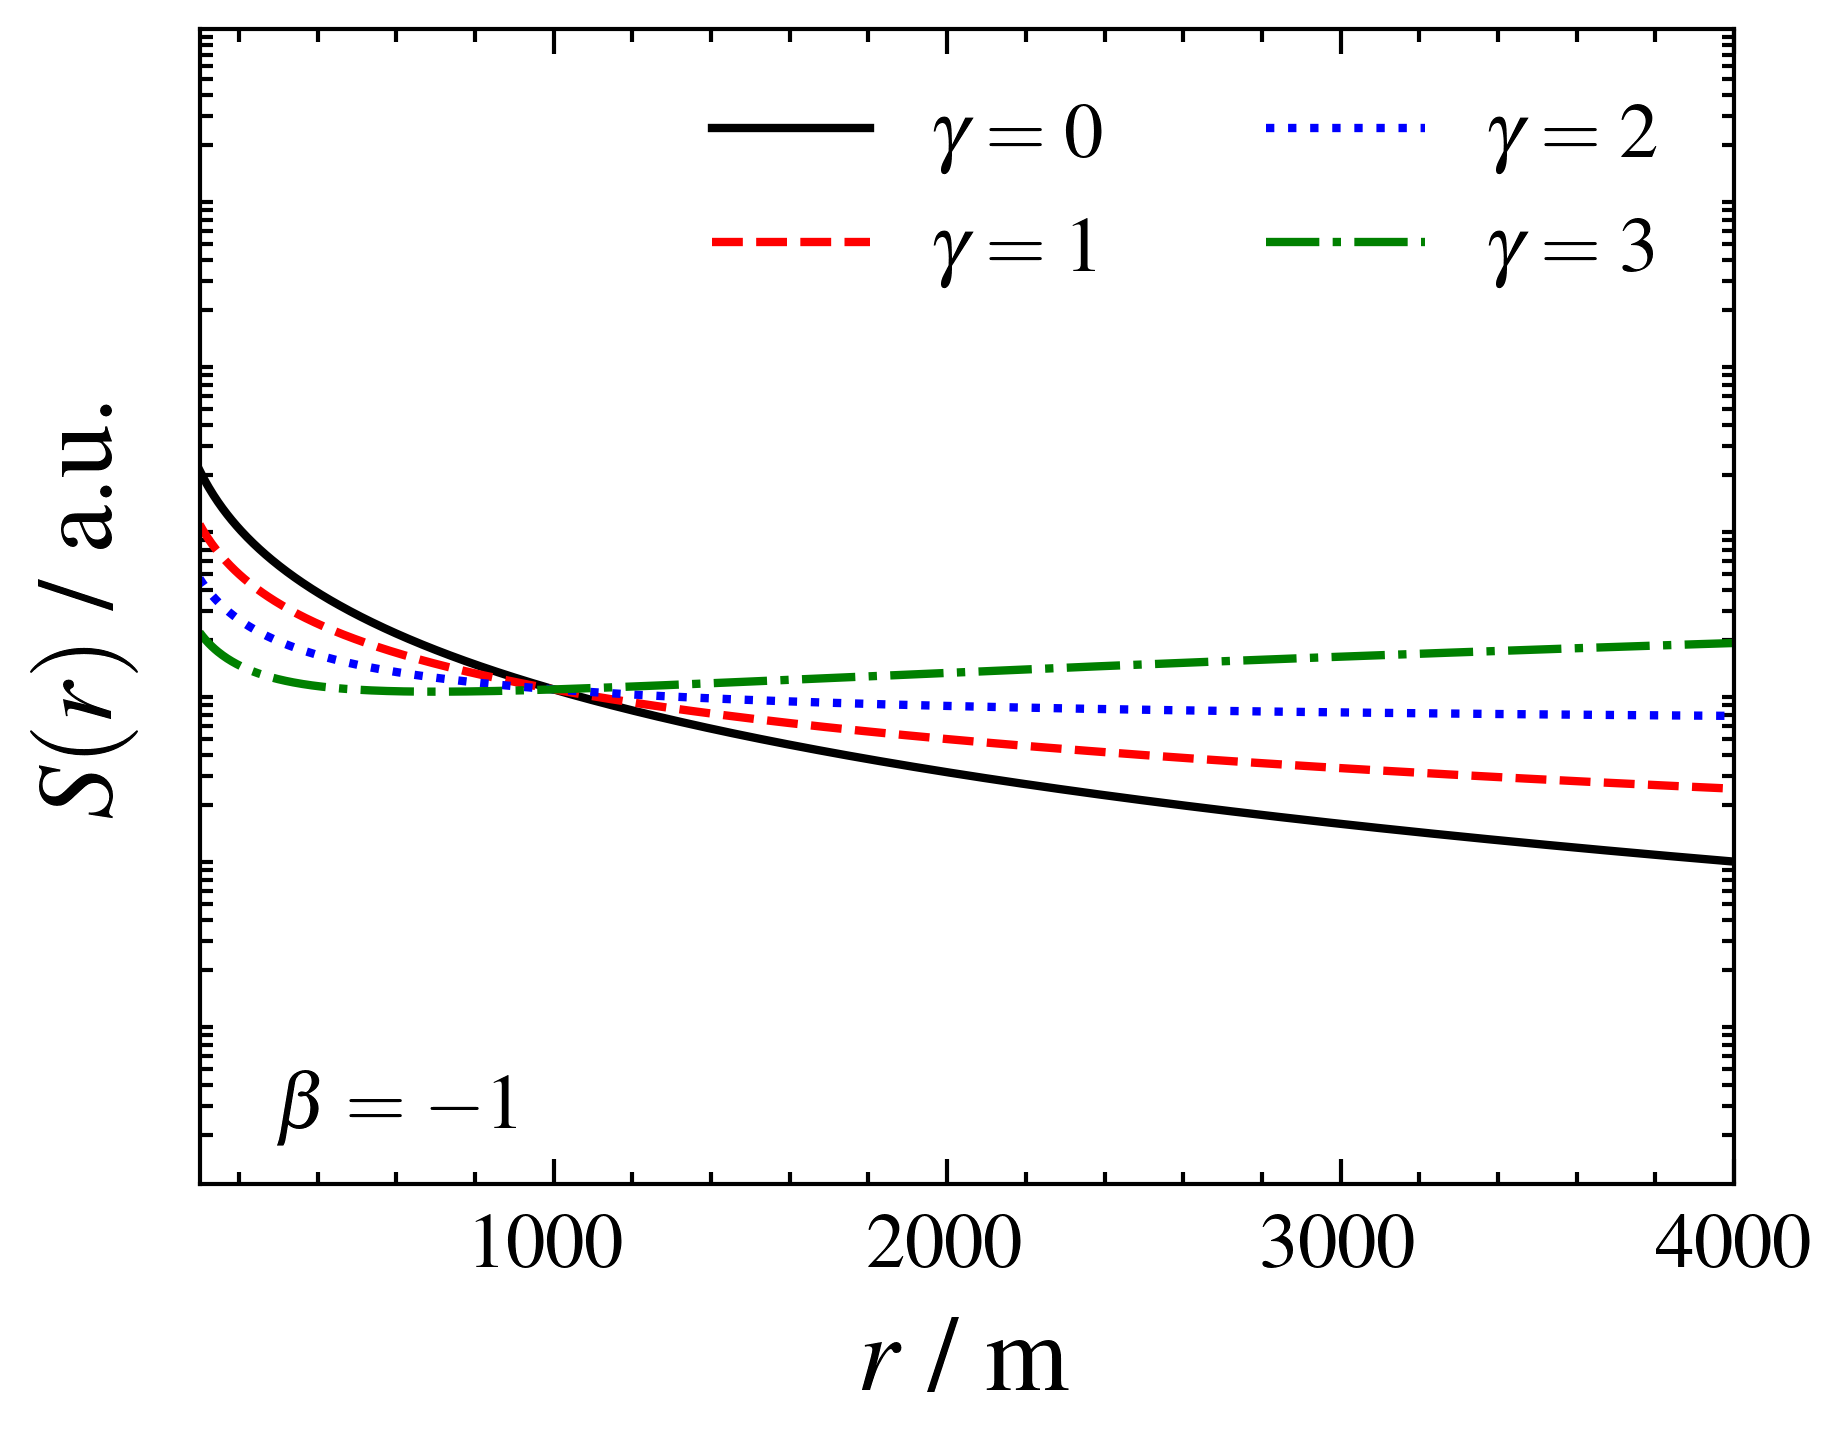

In [75]:
R = np.linspace(100, 4000, 1000)

set_plt_style("double tex")

for beta in np.arange(-1, -5, -1):
    plt.plot(R, ldf(R, beta, 0), marker='none', 
             label=fr"$\beta = {beta}$")
plt.yscale("log")
plt.legend(ncol=2)
plt.xlabel("$r$ / m")
plt.ylabel("$S(r)$ / a.u.")
plt.yticks([])
plt.ylim(1e-3, 1e4)
plt.xlim(100, 4000)
plt.text(0.05, 0.05, r"$\gamma = 0$", transform=plt.gca().transAxes)

plt.axvline(1000, ymax=0.43, ls='-.', lw=0.5, c='k', zorder=0)
plt.axhline(1, xmin=0.25, ls='-.', lw=0.5, c='k', zorder=0)
plt.text(3250, 1.1, "S(1000)", ha='left', va='bottom')

plt.figure()
for gamma in np.arange(0, 4, 1):
    plt.plot(R, ldf(R, -1, gamma), marker='none',
             label=f"$\gamma = {gamma}$")
plt.yscale("log")
plt.legend(ncol=2)
plt.xlabel("$r$ / m")
plt.ylabel("$S(r)$ / a.u.")
plt.yticks([])
plt.ylim(1e-3, 1e4)
plt.xlim(100, 4000)
plt.text(0.05, 0.05, r"$\beta = -1$", transform=plt.gca().transAxes)


<!-- /home/filip/Public/offline/src/Modules/SdReconstruction/ScintillatorLDFFinderKG/NKGLDF.h -->
    Value(const double r, const std::vector<double>& shape)
          const
        {
          const double rRef  = fReferenceDistance;
          const double beta  = shape[0];
          const double gamma = shape[1];

          const double k700  = 700*utl::meter;

          return std::pow(r/rRef, beta) *
            std::pow((k700 + r)/(rRef + k700), beta+gamma);
        }

In [6]:
def ldf(r, beta, gamma):

    r_ref = 1000
    r_scale = 700

    first = np.power(r/r_ref, beta)
    second = np.power((r_scale + r)/(r_ref + r_scale), beta + gamma)

    return first * second